# Cinemath ML Notebook
### Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from scipy.sparse import hstack, csr_matrix

# Metrics — Regression
from sklearn.metrics import r2_score, mean_squared_error

# Metrics — Classification
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, confusion_matrix, ConfusionMatrixDisplay
)

# Regression Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Classification Models
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Step 1 - Data Cleaning & Pre-processing

In [2]:
import os

base = os.path.dirname(os.getcwd())

# Load all cleaned Letterboxd splits
cleaned_path = os.path.join(base, 'final_data', 'letterboxd_review_data',
                            'final_data', 'letterboxd_review_data', 'cleaned_data')
review_files = sorted([
    os.path.join(cleaned_path, f)
    for f in os.listdir(cleaned_path)
    if f.endswith('.csv')
])
df_letter = pd.concat([pd.read_csv(f) for f in review_files], ignore_index=True)

# Load both TMDB movie data parts
movie_files = [
    os.path.join(base, 'final_data', 'tmdb_movie_data', 'movie_data_part1.csv'),
    os.path.join(base, 'final_data', 'tmdb_movie_data', 'movie_data_part2.csv')
]
df_movies = pd.concat([pd.read_csv(f) for f in movie_files], ignore_index=True)

# Load all 14 TMDB description splits
desc_path = os.path.join(base, 'final_data', 'final_tmdb_movie_data')
desc_files = sorted([
    os.path.join(desc_path, f)
    for f in os.listdir(desc_path)
    if f.endswith('.csv')
])
df_desc = pd.concat([pd.read_csv(f) for f in desc_files], ignore_index=True)

print('Review files found :', len(review_files))
print('Letterboxd shape   :', df_letter.shape)
print('Movies shape       :', df_movies.shape)
print('Desc files found   :', len(desc_files))
print('Desc shape         :', df_desc.shape)
print('Desc columns       :', df_desc.columns.tolist())

Review files found : 22
Letterboxd shape   : (7908280, 14)
Movies shape       : (285459, 60)
Desc files found   : 14
Desc shape         : (292700, 5)
Desc columns       : ['tmdb_id', 'tagline', 'overview', 'spoken_languages', 'full_cast']


In [3]:
import ast

# ── LETTERBOXD CLEANING ───────────────────────────────────────────────────
cols_to_drop_letter = ['actors_url', 'director_url']
df_letter = df_letter.drop(columns=[c for c in cols_to_drop_letter if c in df_letter.columns])
df_letter = df_letter.dropna(subset=['rating', 'tmdb_id'])
df_letter = df_letter.drop_duplicates(subset=['username', 'tmdb_id'])

# Genre average rating — how well does each genre rate on average
# This is a genre-level signal, not movie-specific — no leakage
genre_avg = df_letter.groupby('genre')['rating'].mean().reset_index()
genre_avg.columns = ['genre', 'genre_avg_rating']
df_letter = df_letter.merge(genre_avg, on='genre', how='left')

# NOTE: director_avg_rating REMOVED
# Was dominating at 90% feature importance — likely circular leakage
# since director avg may include ratings from the movie being predicted

# ── MOVIES CLEANING ───────────────────────────────────────────────────────
cols_to_drop_movies = [
    # Leakage
    'vote_average', 'vote_count', 'popularity',
    'revenue_x', 'revenue_y', 'profit_x', 'profit_y', 'profit_margin', 'budget_per_min',
    # Duplicates
    'budget_y', 'runtime_y', 'original_language_y', 'in_franchise_y',
    'release_year_x', 'release_year_y',
    # Identifiers
    'movie_id', 'release_date', 'director_name',
    'production_countries', 'production_country_group', 'production_companies',
    # Logically weak / biased
    'budget_x', 'belongs_to_collection', 'has_imdb',
    'has_facebook', 'has_instagram', 'has_twitter', 'social_media_count',
    'producer_count', 'release_month', 'n_production_countries'
    # NOTE: release_type KEPT
]
df_movies = df_movies.drop(columns=[c for c in cols_to_drop_movies if c in df_movies.columns])
df_movies = df_movies.drop_duplicates(subset=['tmdb_id'])

# ── DESCRIPTION CLEANING ──────────────────────────────────────────────────
df_desc['overview']         = df_desc['overview'].fillna('').str.strip()
df_desc['tagline']          = df_desc['tagline'].fillna('').str.strip()
df_desc['full_cast']        = df_desc['full_cast'].fillna('[]')
df_desc['spoken_languages'] = df_desc['spoken_languages'].fillna('').str.strip()
df_desc['overview_word_count'] = df_desc['overview'].apply(lambda x: len(x.split()) if x else 0)
df_desc['tagline_word_count']  = df_desc['tagline'].apply(lambda x: len(x.split()) if x else 0)

# Extract top 3 cast popularity from JSON
def extract_cast_pop(cast_str):
    try:
        cast = ast.literal_eval(cast_str) if isinstance(cast_str, str) else cast_str
        pops = sorted([c.get('popularity', 0) for c in cast], reverse=True)
        return (pops[0] if len(pops) > 0 else 0,
                pops[1] if len(pops) > 1 else 0,
                pops[2] if len(pops) > 2 else 0)
    except:
        return 0, 0, 0

cast_pops = df_desc['full_cast'].apply(extract_cast_pop)
df_desc['desc_cast_1_popularity'] = cast_pops.apply(lambda x: x[0])
df_desc['desc_cast_2_popularity'] = cast_pops.apply(lambda x: x[1])
df_desc['desc_cast_3_popularity'] = cast_pops.apply(lambda x: x[2])
df_desc['desc_cast_total']        = df_desc['desc_cast_1_popularity'] + df_desc['desc_cast_2_popularity'] + df_desc['desc_cast_3_popularity']
df_desc['desc_cast_max']          = df_desc[['desc_cast_1_popularity','desc_cast_2_popularity','desc_cast_3_popularity']].max(axis=1)
df_desc = df_desc.drop_duplicates(subset=['tmdb_id'])

print('df_letter shape:', df_letter.shape)
print('df_movies shape:', df_movies.shape)
print('df_desc shape  :', df_desc.shape)

df_letter shape: (6413130, 13)
df_movies shape: (285459, 29)
df_desc shape  : (292700, 12)


In [4]:
# Aggregate Letterboxd: avg rating, count, genre avg per movie
# director_avg_rating removed — dominated at 90% importance (likely leakage)
review_agg = df_letter.groupby('tmdb_id').agg(
    avg_user_rating=('rating', 'mean'),
    num_letterboxd_ratings=('rating', 'count'),
    genre_avg_rating=('genre_avg_rating', 'first')
).reset_index()

# Merge movies + reviews
df_main = df_movies.merge(review_agg, on='tmdb_id', how='left')
df_main['avg_user_rating']        = df_main['avg_user_rating'].fillna(df_main['avg_user_rating'].median())
df_main['num_letterboxd_ratings'] = df_main['num_letterboxd_ratings'].fillna(0)
df_main['genre_avg_rating']       = df_main['genre_avg_rating'].fillna(df_main['genre_avg_rating'].median())

# Log transform popularity count to reduce skew
df_main['log_letterboxd_ratings'] = np.log1p(df_main['num_letterboxd_ratings'])

# Era flags from release_decade
df_main['is_classic'] = (df_main['release_decade'].fillna(0) <= 1980).astype(int)
df_main['is_modern']  = (df_main['release_decade'].fillna(0) >= 2010).astype(int)
df_main['is_golden']  = ((df_main['release_decade'].fillna(0) >= 1940) & (df_main['release_decade'].fillna(0) <= 1970)).astype(int)

# Merge description data
df_main = df_main.merge(
    df_desc[['tmdb_id', 'overview', 'tagline', 'full_cast',
             'overview_word_count', 'tagline_word_count',
             'desc_cast_1_popularity', 'desc_cast_2_popularity', 'desc_cast_3_popularity',
             'desc_cast_total', 'desc_cast_max']],
    on='tmdb_id', how='left'
)
df_main['overview']               = df_main['overview'].fillna('')
df_main['tagline']                = df_main['tagline'].fillna('')
df_main['full_cast']              = df_main['full_cast'].fillna('')
df_main['overview_word_count']    = df_main['overview_word_count'].fillna(0)
df_main['tagline_word_count']     = df_main['tagline_word_count'].fillna(0)
df_main['desc_cast_1_popularity'] = df_main['desc_cast_1_popularity'].fillna(0)
df_main['desc_cast_2_popularity'] = df_main['desc_cast_2_popularity'].fillna(0)
df_main['desc_cast_3_popularity'] = df_main['desc_cast_3_popularity'].fillna(0)
df_main['desc_cast_total']        = df_main['desc_cast_total'].fillna(0)
df_main['desc_cast_max']          = df_main['desc_cast_max'].fillna(0)

# Drop tmdb_id now that all merges are done
df_main = df_main.drop(columns=['tmdb_id'], errors='ignore')
df_main = df_main.dropna(subset=['avg_user_rating'])

print('df_main shape  :', df_main.shape)
print('df_main columns:', df_main.columns.tolist())

df_main shape  : (285459, 45)
df_main columns: ['release_decade', 'movie_age', 'name', 'runtime_x', 'in_franchise_x', 'original_language_x', 'release_type', 'production_company_count', 'is_major_studio', 'is_us_production', 'cast_size', 'cast_1_popularity', 'cast_2_popularity', 'cast_3_popularity', 'director_popularity', 'director_prior_films', 'keywords', 'keyword_count', 'kw_independent_film', 'kw_animation', 'kw_superhero', 'kw_remake', 'kw_based_on_true_story', 'kw_sequel', 'kw_based_on_novel', 'kw_documentary', 'kw_direct-to-video', 'star_power', 'avg_user_rating', 'num_letterboxd_ratings', 'genre_avg_rating', 'log_letterboxd_ratings', 'is_classic', 'is_modern', 'is_golden', 'overview', 'tagline', 'full_cast', 'overview_word_count', 'tagline_word_count', 'desc_cast_1_popularity', 'desc_cast_2_popularity', 'desc_cast_3_popularity', 'desc_cast_total', 'desc_cast_max']


In [5]:
# TF-IDF on all text: name + keywords + overview + tagline + full_cast
df_main['name']      = df_main['name'].fillna('')
df_main['keywords']  = df_main['keywords'].fillna('')

df_main['text_features'] = (
    df_main['name'] + ' ' +
    df_main['keywords'] + ' ' +
    df_main['overview'] + ' ' +
    df_main['tagline'] + ' ' +
    df_main['full_cast']
)

tfidf = TfidfVectorizer(max_features=100, stop_words='english')
tfidf_matrix = tfidf.fit_transform(df_main['text_features'])

svd = TruncatedSVD(n_components=20, random_state=42)
tfidf_reduced = svd.fit_transform(tfidf_matrix)
tfidf_df = pd.DataFrame(
    tfidf_reduced,
    columns=[f'tfidf_svd_{i}' for i in range(20)],
    index=df_main.index
)

print(f'TF-IDF matrix     : {tfidf_matrix.shape}')
print(f'After SVD         : {tfidf_df.shape}')
print(f'Variance explained: {svd.explained_variance_ratio_.sum():.2%}')

TF-IDF matrix     : (285459, 100)
After SVD         : (285459, 20)
Variance explained: 70.60%


In [6]:
# One-hot encode original_language_x and release_type
cat_cols = ['original_language_x', 'release_type']
cat_cols = [c for c in cat_cols if c in df_main.columns]
df_encoded = pd.get_dummies(df_main, columns=cat_cols)

# Drop all raw text columns — already captured in TF-IDF
drop_text_cols = [
    'name', 'keywords', 'text_features',
    'overview', 'tagline', 'full_cast', 'spoken_languages'
]
df_encoded = df_encoded.drop(columns=[c for c in drop_text_cols if c in df_encoded.columns])

# Convert bool and object to int
bool_cols = df_encoded.select_dtypes(include=['bool']).columns.tolist()
obj_cols  = df_encoded.select_dtypes(include=['object']).columns.tolist()
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
for col in obj_cols:
    df_encoded[col] = pd.to_numeric(df_encoded[col], errors='coerce').fillna(0).astype(int)

# Keep only numeric
df_numeric = df_encoded.select_dtypes(include=[np.number])
df_numeric = df_numeric.fillna(0)

df_final = pd.concat([df_numeric, tfidf_df], axis=1)

print('df_final shape:', df_final.shape)
print('Features:', df_final.columns.tolist())

df_final shape: (285459, 215)
Features: ['release_decade', 'movie_age', 'runtime_x', 'in_franchise_x', 'production_company_count', 'is_major_studio', 'is_us_production', 'cast_size', 'cast_1_popularity', 'cast_2_popularity', 'cast_3_popularity', 'director_popularity', 'director_prior_films', 'keyword_count', 'kw_independent_film', 'kw_animation', 'kw_superhero', 'kw_remake', 'kw_based_on_true_story', 'kw_sequel', 'kw_based_on_novel', 'kw_documentary', 'kw_direct-to-video', 'star_power', 'avg_user_rating', 'num_letterboxd_ratings', 'genre_avg_rating', 'log_letterboxd_ratings', 'is_classic', 'is_modern', 'is_golden', 'overview_word_count', 'tagline_word_count', 'desc_cast_1_popularity', 'desc_cast_2_popularity', 'desc_cast_3_popularity', 'desc_cast_total', 'desc_cast_max', 'original_language_x_ab', 'original_language_x_af', 'original_language_x_ak', 'original_language_x_am', 'original_language_x_ar', 'original_language_x_as', 'original_language_x_ay', 'original_language_x_az', 'original_

# Regression Track

In [7]:
# Regression — predict avg_user_rating
X_reg = df_final.drop(columns=['avg_user_rating'], errors='ignore')
y_reg = df_main['avg_user_rating'].values

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=42
)

scaler_reg = StandardScaler()
X_reg_train_scaled = scaler_reg.fit_transform(X_reg_train)
X_reg_test_scaled  = scaler_reg.transform(X_reg_test)

print('X_reg_train:', X_reg_train.shape)
print('X_reg_test :', X_reg_test.shape)

X_reg_train: (214094, 214)
X_reg_test : (71365, 214)


# Classication Track

In [8]:
# Classification — bin avg_user_rating into 3 categories
# Bad: < 2.5 | Mid: 2.5 - 3.5 | Good: > 3.5
def rating_to_class(r):
    if r < 2.5:    return 0  # Bad
    elif r <= 3.5: return 1  # Mid
    else:          return 2  # Good

y_clf = df_main['avg_user_rating'].apply(rating_to_class).values

print('Class distribution:')
unique, counts = np.unique(y_clf, return_counts=True)
for u, c in zip(unique, counts):
    label = ['Bad', 'Mid', 'Good'][u]
    print(f'  {label}: {c} ({c/len(y_clf):.1%})')

X_clf = df_final.drop(columns=['avg_user_rating'], errors='ignore')

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.25, random_state=42, stratify=y_clf
)

scaler_clf = StandardScaler()
X_clf_train_scaled = scaler_clf.fit_transform(X_clf_train)
X_clf_test_scaled  = scaler_clf.transform(X_clf_test)

print('X_clf_train:', X_clf_train.shape)
print('X_clf_test :', X_clf_test.shape)

Class distribution:
  Bad: 19684 (6.9%)
  Mid: 245494 (86.0%)
  Good: 20281 (7.1%)
X_clf_train: (214094, 214)
X_clf_test : (71365, 214)


In [9]:
# Evaluation helpers
def evaluate_reg(name, y_train, y_train_pred, y_test, y_test_pred):
    print(f'{name}')
    print(f'  Train R²  : {r2_score(y_train, y_train_pred):.4f}')
    print(f'  Test  R²  : {r2_score(y_test,  y_test_pred):.4f}')
    print(f'  Test  RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.4f}\n')

def evaluate_clf(name, y_train, y_train_pred, y_test, y_test_pred):
    print(f'{name}')
    print(f'  Train Accuracy: {accuracy_score(y_train, y_train_pred):.4f}')
    print(f'  Test  Accuracy: {accuracy_score(y_test,  y_test_pred):.4f}')
    print(f'  Test  F1 Score: {f1_score(y_test, y_test_pred, average="weighted"):.4f}\n')

def plot_confusion(name, y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Bad', 'Mid', 'Good'])
    disp.plot(cmap='Blues')
    plt.title(f'{name} — Confusion Matrix')
    plt.tight_layout()
    plt.show()

# Step 2 - Baseline: Linear Regression (OLS)

In [10]:
lr = LinearRegression()
lr.fit(X_reg_train_scaled, y_reg_train)

evaluate_reg(
    'Linear Regression (OLS)',
    y_reg_train, lr.predict(X_reg_train_scaled),
    y_reg_test,  lr.predict(X_reg_test_scaled)
)

Linear Regression (OLS)
  Train R²  : 0.1590
  Test  R²  : 0.1568
  Test  RMSE: 0.3871



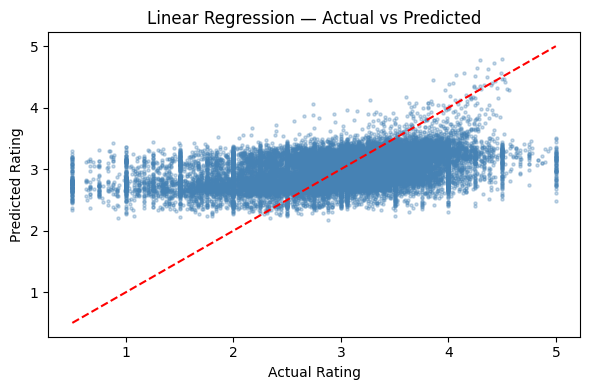

In [11]:
plt.figure(figsize=(6, 4))
plt.scatter(y_reg_test, lr.predict(X_reg_test_scaled), alpha=0.3, s=5, color='steelblue')
plt.plot([y_reg_test.min(), y_reg_test.max()], [y_reg_test.min(), y_reg_test.max()], 'r--', lw=1.5)
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title('Linear Regression — Actual vs Predicted')
plt.tight_layout()
plt.show()

# Step 3 — Regularized Linear Models

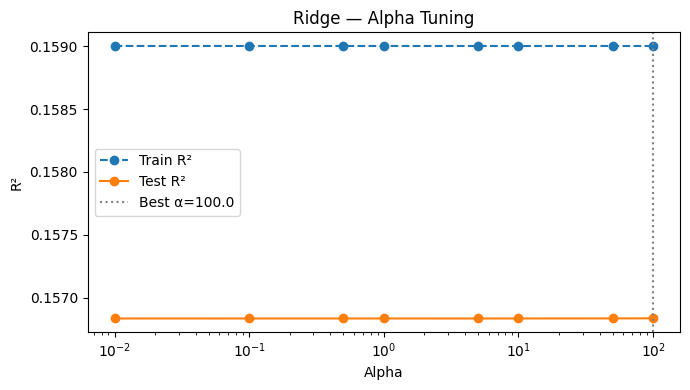

In [12]:
ridge_train_r2, ridge_test_r2 = [], []
alphas = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]

for a in alphas:
    m = Ridge(alpha=a).fit(X_reg_train_scaled, y_reg_train)
    ridge_train_r2.append(r2_score(y_reg_train, m.predict(X_reg_train_scaled)))
    ridge_test_r2.append(r2_score(y_reg_test,   m.predict(X_reg_test_scaled)))

best_alpha_ridge = alphas[np.argmax(ridge_test_r2)]

plt.figure(figsize=(7, 4))
plt.plot(alphas, ridge_train_r2, 'o--', label='Train R²')
plt.plot(alphas, ridge_test_r2,  'o-',  label='Test R²')
plt.xscale('log')
plt.axvline(best_alpha_ridge, color='gray', linestyle=':', label=f'Best α={best_alpha_ridge}')
plt.xlabel('Alpha')
plt.ylabel('R²')
plt.title('Ridge — Alpha Tuning')
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
ridge = Ridge(alpha=best_alpha_ridge).fit(X_reg_train_scaled, y_reg_train)

evaluate_reg(
    f'Ridge Regression (α={best_alpha_ridge})',
    y_reg_train, ridge.predict(X_reg_train_scaled),
    y_reg_test,  ridge.predict(X_reg_test_scaled)
)

Ridge Regression (α=100.0)
  Train R²  : 0.1590
  Test  R²  : 0.1568
  Test  RMSE: 0.3871



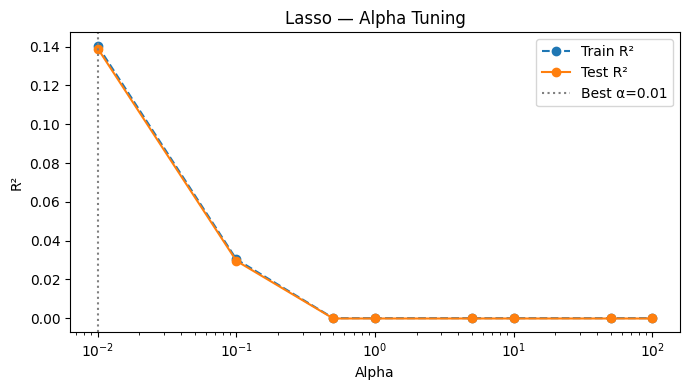

In [14]:
X_train_lasso = X_reg_train_scaled[:50000]
y_train_lasso = y_reg_train[:50000]

lasso_train_r2, lasso_test_r2 = [], []

for a in alphas:
    m = Lasso(alpha=a, max_iter=10000).fit(X_train_lasso, y_train_lasso)
    lasso_train_r2.append(r2_score(y_train_lasso, m.predict(X_train_lasso)))
    lasso_test_r2.append(r2_score(y_reg_test,     m.predict(X_reg_test_scaled)))

best_alpha_lasso = alphas[np.argmax(lasso_test_r2)]

plt.figure(figsize=(7, 4))
plt.plot(alphas, lasso_train_r2, 'o--', label='Train R²')
plt.plot(alphas, lasso_test_r2,  'o-',  label='Test R²')
plt.xscale('log')
plt.axvline(best_alpha_lasso, color='gray', linestyle=':', label=f'Best α={best_alpha_lasso}')
plt.xlabel('Alpha')
plt.ylabel('R²')
plt.title('Lasso — Alpha Tuning')
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
lasso = Lasso(alpha=best_alpha_lasso, max_iter=10000).fit(X_train_lasso, y_train_lasso)

evaluate_reg(
    f'Lasso Regression (α={best_alpha_lasso}, sample=50k)',
    y_train_lasso, lasso.predict(X_train_lasso),
    y_reg_test,    lasso.predict(X_reg_test_scaled)
)

Lasso Regression (α=0.01, sample=50k)
  Train R²  : 0.1404
  Test  R²  : 0.1390
  Test  RMSE: 0.3911



# Step 4 — KNN Regression

In [ ]:
X_train_knn = X_reg_train_scaled[:10000]
y_train_knn = y_reg_train[:10000]

knn_train_r2, knn_test_r2 = [], []
k_range = range(1, 11)

for k in k_range:
    m = KNeighborsRegressor(n_neighbors=k, n_jobs=-1, algorithm='ball_tree').fit(X_train_knn, y_train_knn)
    knn_train_r2.append(r2_score(y_train_knn, m.predict(X_train_knn)))
    knn_test_r2.append(r2_score(y_reg_test,   m.predict(X_reg_test_scaled)))

best_k = list(k_range)[np.argmax(knn_test_r2)]

plt.figure(figsize=(7, 4))
plt.plot(k_range, knn_train_r2, 'o--', label='Train R²')
plt.plot(k_range, knn_test_r2,  'o-',  label='Test R²')
plt.axvline(best_k, color='gray', linestyle=':', label=f'Best k={best_k}')
plt.xlabel('n_neighbors (k)')
plt.ylabel('R²')
plt.title('KNN Regression — k Tuning (10k sample)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
knn = KNeighborsRegressor(n_neighbors=best_k, n_jobs=-1, algorithm='ball_tree')
knn.fit(X_train_knn, y_train_knn)

evaluate_reg(
    f'KNN Regression (k={best_k}, sample=10k)',
    y_train_knn, knn.predict(X_train_knn),
    y_reg_test,  knn.predict(X_reg_test_scaled)
)

KNN Regression (k=10, sample=10k)
  Train R²  : 0.3207
  Test  R²  : 0.1291
  Test  RMSE: 0.3934



# Step 5 — Decision Tree

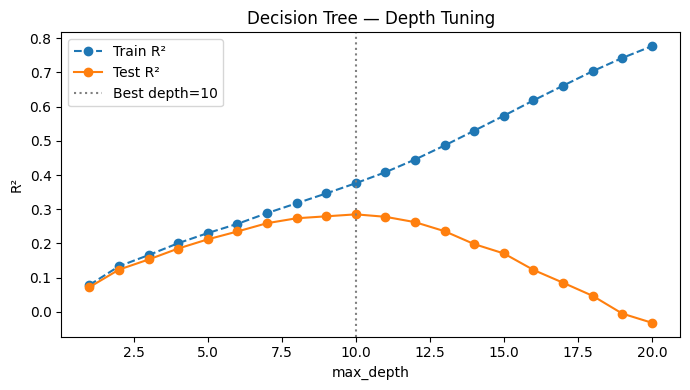

In [ ]:
dt_train_r2, dt_test_r2 = [], []
depth_range = range(1, 21)

for d in depth_range:
    m = DecisionTreeRegressor(max_depth=d, random_state=42).fit(X_reg_train, y_reg_train)
    dt_train_r2.append(r2_score(y_reg_train, m.predict(X_reg_train)))
    dt_test_r2.append(r2_score(y_reg_test,   m.predict(X_reg_test)))

best_depth = list(depth_range)[np.argmax(dt_test_r2)]

plt.figure(figsize=(7, 4))
plt.plot(depth_range, dt_train_r2, 'o--', label='Train R²')
plt.plot(depth_range, dt_test_r2,  'o-',  label='Test R²')
plt.axvline(best_depth, color='gray', linestyle=':', label=f'Best depth={best_depth}')
plt.xlabel('max_depth')
plt.ylabel('R²')
plt.title('Decision Tree — Depth Tuning')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
dt = DecisionTreeRegressor(max_depth=best_depth, random_state=42).fit(X_reg_train, y_reg_train)

evaluate_reg(
    f'Decision Tree (max_depth={best_depth})',
    y_reg_train, dt.predict(X_reg_train),
    y_reg_test,  dt.predict(X_reg_test)
)

Decision Tree (max_depth=10)
  Train R²  : 0.3761
  Test  R²  : 0.2850
  Test  RMSE: 0.3564



# Step 6 — Random Forest

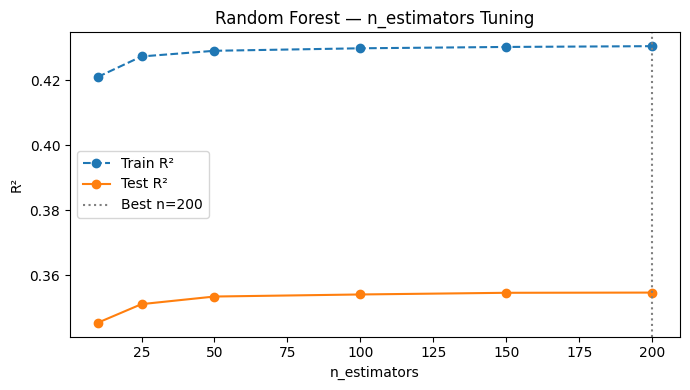

In [ ]:
rf_train_r2, rf_test_r2 = [], []
estimator_range = [10, 25, 50, 100, 150, 200]

for n in estimator_range:
    m = RandomForestRegressor(n_estimators=n, max_depth=best_depth, random_state=42, n_jobs=-1)
    m.fit(X_reg_train, y_reg_train)
    rf_train_r2.append(r2_score(y_reg_train, m.predict(X_reg_train)))
    rf_test_r2.append(r2_score(y_reg_test,   m.predict(X_reg_test)))

best_n_estimators = estimator_range[np.argmax(rf_test_r2)]

plt.figure(figsize=(7, 4))
plt.plot(estimator_range, rf_train_r2, 'o--', label='Train R²')
plt.plot(estimator_range, rf_test_r2,  'o-',  label='Test R²')
plt.axvline(best_n_estimators, color='gray', linestyle=':', label=f'Best n={best_n_estimators}')
plt.xlabel('n_estimators')
plt.ylabel('R²')
plt.title('Random Forest — n_estimators Tuning')
plt.legend()
plt.tight_layout()
plt.show()

Random Forest (n=200, depth=10)
  Train R²  : 0.4305
  Test  R²  : 0.3547
  Test  RMSE: 0.3386



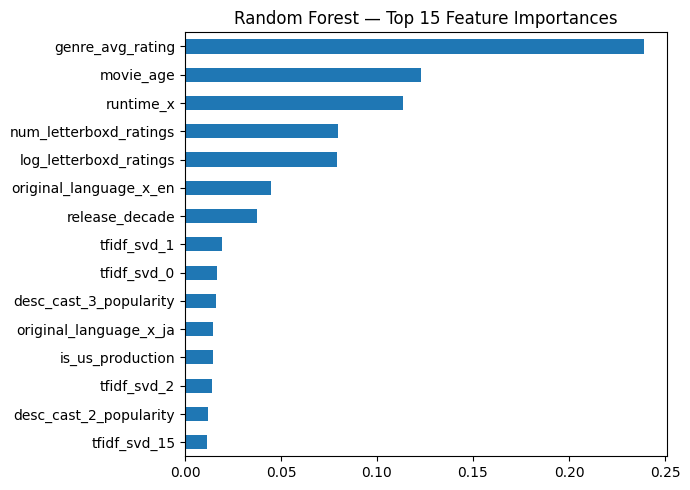

In [ ]:
rf = RandomForestRegressor(
    n_estimators=best_n_estimators,
    max_depth=best_depth,
    random_state=42,
    n_jobs=-1
).fit(X_reg_train, y_reg_train)

evaluate_reg(
    f'Random Forest (n={best_n_estimators}, depth={best_depth})',
    y_reg_train, rf.predict(X_reg_train),
    y_reg_test,  rf.predict(X_reg_test)
)

feat_imp = pd.Series(rf.feature_importances_, index=X_reg_train.columns)
feat_imp.nlargest(15).sort_values().plot(
    kind='barh', figsize=(7, 5), title='Random Forest — Top 15 Feature Importances'
)
plt.tight_layout()
plt.show()

# Step 7 — Gradient Boosting

In [ ]:
gb_train_r2, gb_test_r2 = [], []
lr_range = [0.05, 0.1, 0.2, 0.3]

for lr_val in lr_range:
    m = GradientBoostingRegressor(
        n_estimators=300, max_depth=5,
        learning_rate=lr_val,
        subsample=0.8, max_features=0.8,
        random_state=42
    ).fit(X_reg_train, y_reg_train)
    gb_train_r2.append(r2_score(y_reg_train, m.predict(X_reg_train)))
    gb_test_r2.append(r2_score(y_reg_test,   m.predict(X_reg_test)))

best_lr = lr_range[np.argmax(gb_test_r2)]

plt.figure(figsize=(7, 4))
plt.plot(lr_range, gb_train_r2, 'o--', label='Train R²')
plt.plot(lr_range, gb_test_r2,  'o-',  label='Test R²')
plt.axvline(best_lr, color='gray', linestyle=':', label=f'Best lr={best_lr}')
plt.xlabel('Learning Rate')
plt.ylabel('R²')
plt.title('Gradient Boosting — Learning Rate Tuning')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
gb = GradientBoostingRegressor(
    n_estimators=300, max_depth=5,
    learning_rate=best_lr,
    subsample=0.8, max_features=0.8,
    random_state=42
).fit(X_reg_train, y_reg_train)

evaluate_reg(
    f'Gradient Boosting (lr={best_lr}, n=300, depth=5)',
    y_reg_train, gb.predict(X_reg_train),
    y_reg_test,  gb.predict(X_reg_test)
)

feat_imp_gb = pd.Series(gb.feature_importances_, index=X_reg_train.columns)
feat_imp_gb.nlargest(15).sort_values().plot(
    kind='barh', figsize=(7, 5), title='Gradient Boosting — Top 15 Feature Importances'
)
plt.tight_layout()
plt.show()

# Step 8 — Model Comparison

In [ ]:
# ── REGRESSION COMPARISON ────────────────────────────────────────────────
reg_models = {
    'Linear Regression': (lr,    X_reg_test_scaled),
    'Ridge':             (ridge, X_reg_test_scaled),
    'Lasso':             (lasso, X_reg_test_scaled),
    'KNN':               (knn,   X_reg_test_scaled),
    'Decision Tree':     (dt,    X_reg_test),
    'Random Forest':     (rf,    X_reg_test),
    'Gradient Boosting': (gb,    X_reg_test),
}

reg_results = []
for name, (model, X_eval) in reg_models.items():
    preds = model.predict(X_eval)
    reg_results.append({
        'Model':     name,
        'Test R²':   round(r2_score(y_reg_test, preds), 4),
        'Test RMSE': round(np.sqrt(mean_squared_error(y_reg_test, preds)), 4)
    })

reg_df = pd.DataFrame(reg_results).sort_values('Test R²', ascending=False).reset_index(drop=True)
print('\n=== REGRESSION RESULTS ===')
print(reg_df)

# ── CLASSIFICATION MODELS ─────────────────────────────────────────────────
print('\n=== CLASSIFICATION MODELS ===')

# Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
log_reg.fit(X_clf_train_scaled, y_clf_train)
evaluate_clf('Logistic Regression',
    y_clf_train, log_reg.predict(X_clf_train_scaled),
    y_clf_test,  log_reg.predict(X_clf_test_scaled))
plot_confusion('Logistic Regression', y_clf_test, log_reg.predict(X_clf_test_scaled))

# Ridge Classifier
ridge_clf = RidgeClassifier(class_weight='balanced')
ridge_clf.fit(X_clf_train_scaled, y_clf_train)
evaluate_clf('Ridge Classifier',
    y_clf_train, ridge_clf.predict(X_clf_train_scaled),
    y_clf_test,  ridge_clf.predict(X_clf_test_scaled))
plot_confusion('Ridge Classifier', y_clf_test, ridge_clf.predict(X_clf_test_scaled))

# KNN Classifier
knn_clf = KNeighborsClassifier(n_neighbors=10, n_jobs=-1)
knn_clf.fit(X_clf_train_scaled, y_clf_train)
evaluate_clf('KNN Classifier',
    y_clf_train, knn_clf.predict(X_clf_train_scaled),
    y_clf_test,  knn_clf.predict(X_clf_test_scaled))
plot_confusion('KNN Classifier', y_clf_test, knn_clf.predict(X_clf_test_scaled))

# Decision Tree Classifier
dt_clf = DecisionTreeClassifier(max_depth=best_depth, random_state=42, class_weight='balanced')
dt_clf.fit(X_clf_train, y_clf_train)
evaluate_clf('Decision Tree Classifier',
    y_clf_train, dt_clf.predict(X_clf_train),
    y_clf_test,  dt_clf.predict(X_clf_test))
plot_confusion('Decision Tree Classifier', y_clf_test, dt_clf.predict(X_clf_test))

# Random Forest Classifier
rf_clf = RandomForestClassifier(
    n_estimators=best_n_estimators, max_depth=best_depth,
    random_state=42, n_jobs=-1, class_weight='balanced'
)
rf_clf.fit(X_clf_train, y_clf_train)
evaluate_clf('Random Forest Classifier',
    y_clf_train, rf_clf.predict(X_clf_train),
    y_clf_test,  rf_clf.predict(X_clf_test))
plot_confusion('Random Forest Classifier', y_clf_test, rf_clf.predict(X_clf_test))

# Gradient Boosting Classifier
gb_clf = GradientBoostingClassifier(
    n_estimators=300, max_depth=5,
    learning_rate=best_lr,
    subsample=0.8, max_features=0.8,
    random_state=42
)
gb_clf.fit(X_clf_train, y_clf_train)
evaluate_clf('Gradient Boosting Classifier',
    y_clf_train, gb_clf.predict(X_clf_train),
    y_clf_test,  gb_clf.predict(X_clf_test))
plot_confusion('Gradient Boosting Classifier', y_clf_test, gb_clf.predict(X_clf_test))

In [ ]:
# ── FINAL COMPARISON TABLES ──────────────────────────────────────────────
print('=== REGRESSION ===')
print(reg_df)

clf_models = {
    'Logistic Regression':        (log_reg, X_clf_test_scaled),
    'Ridge Classifier':           (ridge_clf, X_clf_test_scaled),
    'KNN Classifier':             (knn_clf, X_clf_test_scaled),
    'Decision Tree Classifier':   (dt_clf, X_clf_test),
    'Random Forest Classifier':   (rf_clf, X_clf_test),
    'Gradient Boosting Classifier': (gb_clf, X_clf_test),
}

clf_results = []
for name, (model, X_eval) in clf_models.items():
    preds = model.predict(X_eval)
    clf_results.append({
        'Model':    name,
        'Accuracy': round(accuracy_score(y_clf_test, preds), 4),
        'F1 Score': round(f1_score(y_clf_test, preds, average='weighted'), 4),
    })

clf_df = pd.DataFrame(clf_results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
print('\n=== CLASSIFICATION ===')
print(clf_df)

# Plot both
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

reg_df.plot(x='Model', y='Test R²', kind='bar',
    ax=axes[0], legend=False, color='steelblue', edgecolor='white')
axes[0].set_title('Regression — Test R²')
axes[0].set_xticklabels(reg_df['Model'], rotation=30, ha='right')

clf_df.plot(x='Model', y='Accuracy', kind='bar',
    ax=axes[1], legend=False, color='tomato', edgecolor='white')
axes[1].set_title('Classification — Accuracy')
axes[1].set_xticklabels(clf_df['Model'], rotation=30, ha='right')

plt.tight_layout()
plt.show()

# ── PREDICTION DEMO ───────────────────────────────────────────────────────
sample_idx = 0
sample_reg = X_reg_test.iloc[[sample_idx]]
sample_clf = X_clf_test.iloc[[sample_idx]]

actual_rating = y_reg_test[sample_idx]
pred_rating   = gb.predict(sample_reg)[0]
pred_class    = ['Bad', 'Mid', 'Good'][gb_clf.predict(sample_clf)[0]]
proba         = gb_clf.predict_proba(sample_clf)[0]

print(f'Actual Rating    : {actual_rating:.2f}')
print(f'Predicted Rating : {pred_rating:.2f}')
print(f'Predicted Class  : {pred_class}')
print(f'Confidence       : Bad={proba[0]:.1%}  Mid={proba[1]:.1%}  Good={proba[2]:.1%}')